# LushProtein — Decile: Time-Based Customer Behaviour

**Goal:** Complement the vertical (Profit / AOF profile) analysis from `lushprotein_decile.ipynb` with a
**horizontal, time-based lens** — when do customers make their 2nd and 3rd purchase? How quickly
do they churn? What % of each decile is still active at 3 / 6 / 12 months?

**Decile assignments used:** loaded from `outputs_finals/decile_customer_table.csv` (generated by
`lushprotein_decile.ipynb`) — do not re-run decile logic here.

---

### Analyses in this notebook

| Section | Question |
|---------|----------|
| 3 | Build per-customer order timeline (1st / 2nd / 3rd order dates, inter-purchase gaps) |
| 4 | Repeat purchase funnel — % with >=2, >=3, >=4 orders by decile |
| 5 | Time to 2nd purchase — distribution of days from 1st to 2nd order |
| 6 | Time to 3rd purchase — days from 1st to 3rd, and 2nd to 3rd (cadence) |
| 7 | Recency / churn signal — days since last order per decile |
| 8 | Retention at milestones — % who repeated within 3 / 6 / 12 months of first purchase |
| 9 | Customer lifespan — days from first to last order |
| 10 | Export |

---

### Decile key (from `lushprotein_decile.ipynb`)
- **`profit_decile`** — D1 = highest Profit (Revenue minus COGS). D5 = lowest.
- **`order_freq_decile`** — D1 = most orders placed. D5 = fewest.
- Pool: `finals_eligible == True`, excluding 100%-Marketplace accounts — 4,290 customers.

## 0. Setup

In [146]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# Paths
BASE_DIR   = Path(".").resolve().parent   # assumes notebook is inside EDA/
FINALS_DIR = BASE_DIR / "EDA" / "outputs_finals"

# Churn threshold: customers with no order in this many days are flagged as likely churned
CHURN_DAYS = 180
AT_RISK_DAYS = 90   # grey zone: no purchase in 90-180 days

N_TIERS = 5
TIER_ORDER = [f"D{i}" for i in range(1, N_TIERS + 1)]

print("Finals dir:", FINALS_DIR)
print("Files available:", [f.name for f in FINALS_DIR.iterdir()])

Finals dir: C:\Users\saeli\Downloads\LushProtein prj\lushprotein\EDA\outputs_finals
Files available: ['customers.parquet', 'decile1_profit.png', 'decile2_frequency.png', 'decile_contribution_margin.png', 'decile_customer_table.csv', 'decile_order_frequency.png', 'decile_overlap_heatmap.png', 'decile_profit.png', 'decile_timebased_table.csv', 'discounts.parquet', 'do_not_use_these', 'equal_revenue_slicing.png', 'lens2_migration_heatmap.png', 'lines.parquet', 'lines_sku_analysis.parquet', 'manifest.json', 'margin_enrichment_summary.json', 'next_churned_customers.csv', 'next_t1_dropped.csv', 'next_t5_to_t1_jumpers.csv', 'next_tier_revenue_change.csv', 'orders.parquet', 'products.parquet', 'rc_checkout.parquet', 'rc_churned.parquet', 'rc_orders.parquet', 'rc_reactivated.parquet', 'rc_recurring.parquet', 'README.md', 'timebased_customer_lifespan.png', 'timebased_days_to_2nd_purchase.png', 'timebased_days_to_3rd_purchase.png', 'timebased_recency_boxplot.png', 'timebased_recency_status.png', 

## 1. Load Data

Three sources:
- **`decile_customer_table.csv`** — decile assignments (the authoritative output of `lushprotein_decile.ipynb`)
- **`customers.parquet`** — pre-computed time fields: `first_order_date`, `last_order_date`, `second_order_date`, `days_to_second`, `recency_days`, `lifespan_days`
- **`orders.parquet`** — full order-level history needed to compute 3rd purchase date and inter-purchase cadence

In [147]:
decile_csv = pd.read_csv(FINALS_DIR / "decile_customer_table.csv", dtype={"customer_id": str})
cust_raw   = pd.read_parquet(FINALS_DIR / "customers.parquet")
orders_raw = pd.read_parquet(FINALS_DIR / "orders.parquet")

cust_raw["customer_id"] = cust_raw["customer_id"].astype(str)
orders_raw["customer_id"] = orders_raw["customer_id"].astype(str)

print(f"Decile table : {len(decile_csv):,} customers")
print(f"Customers parquet : {len(cust_raw):,} customers")
print(f"Orders parquet : {len(orders_raw):,} orders")
print()
print("Decile columns:", list(decile_csv.columns))

Decile table : 4,290 customers
Customers parquet : 5,694 customers
Orders parquet : 8,955 orders

Decile columns: ['customer_id', 'finals_orders', 'finals_revenue', 'true_gross_profit', 'avg_margin_pct', 'cogs_coverage_pct', 'profit_decile', 'order_freq_decile', 'first_channel', 'first_product_cat', 'first_store', 'ever_subscribed', 'cohort_month', 'acq_year', 'n_categories_ever', 'is_top_cm', 'is_top_freq', 'is_top_both']


## 2. Merge — Build Working Dataset

Join decile assignments with the time-related columns from `customers.parquet`.
The decile pool is already filtered (finals_eligible, no all-marketplace) so we inner-join to keep only the 4,290 in-scope customers.

In [148]:
# Time columns we want from customers.parquet
time_cols = [
    "customer_id",
    "first_order_date", "second_order_date", "last_order_date",
    "days_to_second", "lifespan_days", "recency_days",
    "total_orders",
]

df = decile_csv.merge(
    cust_raw[time_cols],
    on="customer_id",
    how="inner"
)

# Ensure datetime types
for col in ["first_order_date", "second_order_date", "last_order_date"]:
    df[col] = pd.to_datetime(df[col], utc=True)

# Reference date: last day of data
REFERENCE_DATE = orders_raw["order_date"].max()
print(f"Reference date (data end): {REFERENCE_DATE.date()}")

print(f"Working dataset: {len(df):,} customers")
print()
print("Decile value counts (profit):")
print(df["profit_decile"].value_counts().sort_index())

Reference date (data end): 2026-03-30
Working dataset: 4,290 customers

Decile value counts (profit):
profit_decile
D1    858
D2    858
D3    858
D4    858
D5    858
Name: count, dtype: int64


## 3. Compute 3rd-Purchase Timing

`customers.parquet` already provides `days_to_second`. We need to derive the 3rd order date
from `orders.parquet` — restrict to the decile pool, rank each customer's orders, pull rank 3.

In [149]:
# Restrict to the decile pool only
pool_ids = set(df["customer_id"])
orders_pool = orders_raw[orders_raw["customer_id"].isin(pool_ids)].copy()

# De-duplicate to one row per (customer, order) — lines table has multiple rows per order
orders_dedup = (
    orders_pool
    .drop_duplicates(subset=["customer_id", "order_id"])
    .sort_values(["customer_id", "order_date"])
)

# Rank within each customer (1 = earliest)
orders_dedup["order_rank"] = (
    orders_dedup.groupby("customer_id")["order_date"]
    .rank(method="first", ascending=True)
    .astype(int)
)

# Pull first and third order dates
first_orders = orders_dedup[orders_dedup["order_rank"] == 1][["customer_id", "order_date"]].rename(columns={"order_date": "first_order_date_orders"})
third_orders = orders_dedup[orders_dedup["order_rank"] == 3][["customer_id", "order_date"]].rename(columns={"order_date": "third_order_date"})

df = df.merge(third_orders, on="customer_id", how="left")
df = df.merge(first_orders, on="customer_id", how="left")

# Days from 1st to 3rd order
df["days_to_third"] = (
    (df["third_order_date"] - df["first_order_date_orders"]).dt.total_seconds() / 86400
)
# Days from 2nd to 3rd order (cadence between repeat purchases)
df["days_2nd_to_3rd"] = df["days_to_third"] - df["days_to_second"]

n_with_3rd = df["days_to_third"].notna().sum()
print(f"Customers with >=3 orders: {n_with_3rd:,} ({n_with_3rd/len(df):.1%} of pool)")
print()
print("days_to_third sample stats:")
print(df["days_to_third"].describe().round(1))

Customers with >=3 orders: 475 (11.1% of pool)

days_to_third sample stats:
count     475.0
mean      210.3
std       223.8
min         0.0
25%        62.0
50%       131.0
75%       286.0
max      1448.0
Name: days_to_third, dtype: float64


## 4. Repeat Purchase Funnel — % with >=N Orders by Decile

The most fundamental time-based question: what share of each decile ever came back at all?

In [150]:
def repeat_funnel(df, decile_col):
    rows = []
    for tier in TIER_ORDER:
        grp = df[df[decile_col] == tier]
        n = len(grp)
        rows.append({
            decile_col: tier,
            "n_customers": n,
            "pct_2plus": (grp["finals_orders"] >= 2).sum() / n,
            "pct_3plus": (grp["finals_orders"] >= 3).sum() / n,
            "pct_4plus": (grp["finals_orders"] >= 4).sum() / n,
            "pct_5plus": (grp["finals_orders"] >= 5).sum() / n,
        })
    return pd.DataFrame(rows)

funnel_profit   = repeat_funnel(df, "profit_decile")
funnel_freq = repeat_funnel(df, "order_freq_decile")

print("REPEAT PURCHASE FUNNEL — BY PROFIT DECILE")
print(funnel_profit.to_string(index=False, formatters={
    "pct_2plus": "{:.1%}".format, "pct_3plus": "{:.1%}".format,
    "pct_4plus": "{:.1%}".format, "pct_5plus": "{:.1%}".format
}))
print()
print("REPEAT PURCHASE FUNNEL — BY ORDER FREQUENCY DECILE")
print(funnel_freq.to_string(index=False, formatters={
    "pct_2plus": "{:.1%}".format, "pct_3plus": "{:.1%}".format,
    "pct_4plus": "{:.1%}".format, "pct_5plus": "{:.1%}".format
}))

REPEAT PURCHASE FUNNEL — BY PROFIT DECILE
profit_decile  n_customers pct_2plus pct_3plus pct_4plus pct_5plus
           D1          858     73.7%     41.1%     26.6%     17.9%
           D2          858     29.7%      9.9%      4.1%      1.7%
           D3          858     13.8%      2.2%      0.6%      0.2%
           D4          858      9.4%      1.7%      0.5%      0.1%
           D5          858      5.1%      0.3%      0.3%      0.0%

REPEAT PURCHASE FUNNEL — BY ORDER FREQUENCY DECILE
order_freq_decile  n_customers pct_2plus pct_3plus pct_4plus pct_5plus
               D1          858    100.0%     55.4%     32.1%     20.0%
               D2          858     31.7%      0.0%      0.0%      0.0%
               D3          858      0.0%      0.0%      0.0%      0.0%
               D4          858      0.0%      0.0%      0.0%      0.0%
               D5          858      0.0%      0.0%      0.0%      0.0%


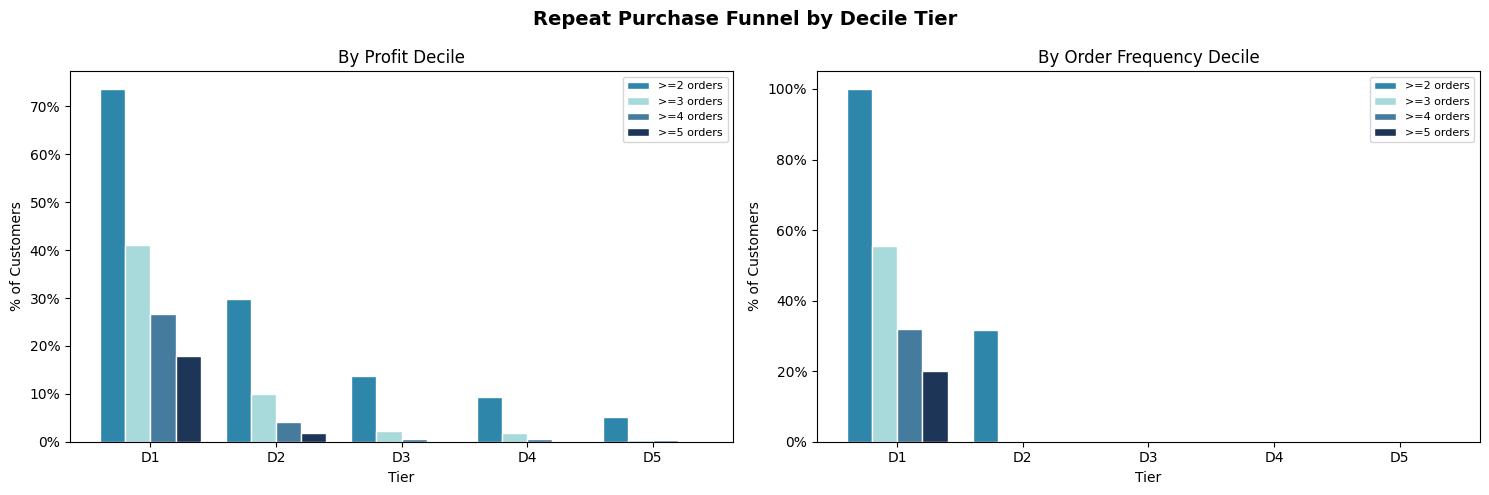

Saved: timebased_repeat_purchase_funnel.png

Key Findings:
- 73.7% of the top-profit customer group (D1) came back for a second purchase,and 41.1% came back for a third.
- The biggest drop happens in D1 to D2.
- In contrast, only 29.7% of D2(profit) returned, and D3–D5(profit) are largely one-time buyers.
- Looking at purchase frequency alone: D3, D4, and D5 are 100% one-time buyers — none ever returned.
- The drop-off from D1 to D2(freq) is steep and consistent across the ≥3, ≥4, ≥5 thresholds.


In [151]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Repeat Purchase Funnel by Decile Tier", fontsize=14, fontweight="bold")

x = np.arange(N_TIERS)
width = 0.2
labels = [">=2 orders", ">=3 orders", ">=4 orders", ">=5 orders"]
cols_plot = ["pct_2plus", "pct_3plus", "pct_4plus", "pct_5plus"]
colors_funnel = ["#2E86AB", "#A8DADC", "#457B9D", "#1D3557"]

for ax, funnel, title in [
    (axes[0], funnel_profit,   "By Profit Decile"),
    (axes[1], funnel_freq, "By Order Frequency Decile"),
]:
    for i, (col, label, color) in enumerate(zip(cols_plot, labels, colors_funnel)):
        bars = ax.bar(x + i * width, funnel[col] * 100, width, label=label, color=color, edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("Tier")
    ax.set_ylabel("% of Customers")
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(TIER_ORDER)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FINALS_DIR / "timebased_repeat_purchase_funnel.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: timebased_repeat_purchase_funnel.png")

# --- Key Findings ---
print("\nKey Findings:")
print(f"""\
- {d1_profit['pct_2plus']:.1%} of the top-profit customer group (D1) came back for a second purchase,\
and {d1_profit['pct_3plus']:.1%} came back for a third.
- The biggest drop happens in D1 to D2.
- In contrast, only {d2_profit['pct_2plus']:.1%} of D2(profit) returned, and D3–D5(profit) are largely one-time buyers.
- Looking at purchase frequency alone: D3, D4, and D5 are 100% one-time buyers — none ever returned.
- The drop-off from D1 to D2(freq) is steep and consistent across the ≥3, ≥4, ≥5 thresholds.""")

## 5. Time to 2nd Purchase

Among customers who made a 2nd purchase, how many days did it take?

Note: `days_to_second` comes from `customers.parquet` (pre-computed, full order history).

In [152]:
def days_to_nth_summary(df, decile_col, days_col, min_orders=None):
    rows = []
    for tier in TIER_ORDER:
        grp = df[df[decile_col] == tier]
        if min_orders:
            grp = grp[grp["finals_orders"] >= min_orders]
        valid = grp[days_col].dropna()
        rows.append({
            decile_col: tier,
            "n_eligible": len(valid),
            "median_days": valid.median(),
            "mean_days":   valid.mean(),
            "p25_days":    valid.quantile(0.25),
            "p75_days":    valid.quantile(0.75),
        })
    return pd.DataFrame(rows)

summary_2nd_profit   = days_to_nth_summary(df, "profit_decile", "days_to_second", min_orders=2)
summary_2nd_freq = days_to_nth_summary(df, "order_freq_decile",          "days_to_second", min_orders=2)

fmt_days = {"median_days": "{:.0f}d".format, "mean_days": "{:.0f}d".format,
            "p25_days": "{:.0f}d".format, "p75_days": "{:.0f}d".format}

print("TIME TO 2nd PURCHASE — BY PROFIT DECILE (customers with >=2 orders)")
print(summary_2nd_profit.to_string(index=False, formatters=fmt_days))
print()
print("TIME TO 2nd PURCHASE — BY ORDER FREQUENCY DECILE (customers with >=2 orders)")
print(summary_2nd_freq.to_string(index=False, formatters=fmt_days))


TIME TO 2nd PURCHASE — BY PROFIT DECILE (customers with >=2 orders)
profit_decile  n_eligible median_days mean_days p25_days p75_days
           D1         632         56d      128d      28d     156d
           D2         255         49d      102d      27d     122d
           D3         118         50d      165d      16d     156d
           D4          81         32d       82d      11d      92d
           D5          44          0d       40d       0d      14d

TIME TO 2nd PURCHASE — BY ORDER FREQUENCY DECILE (customers with >=2 orders)
order_freq_decile  n_eligible median_days mean_days p25_days p75_days
               D1         858         44d      103d      23d     120d
               D2         272         72d      170d      17d     214d
               D3           0         NaN       NaN      NaN      NaN
               D4           0         NaN       NaN      NaN      NaN
               D5           0         NaN       NaN      NaN      NaN


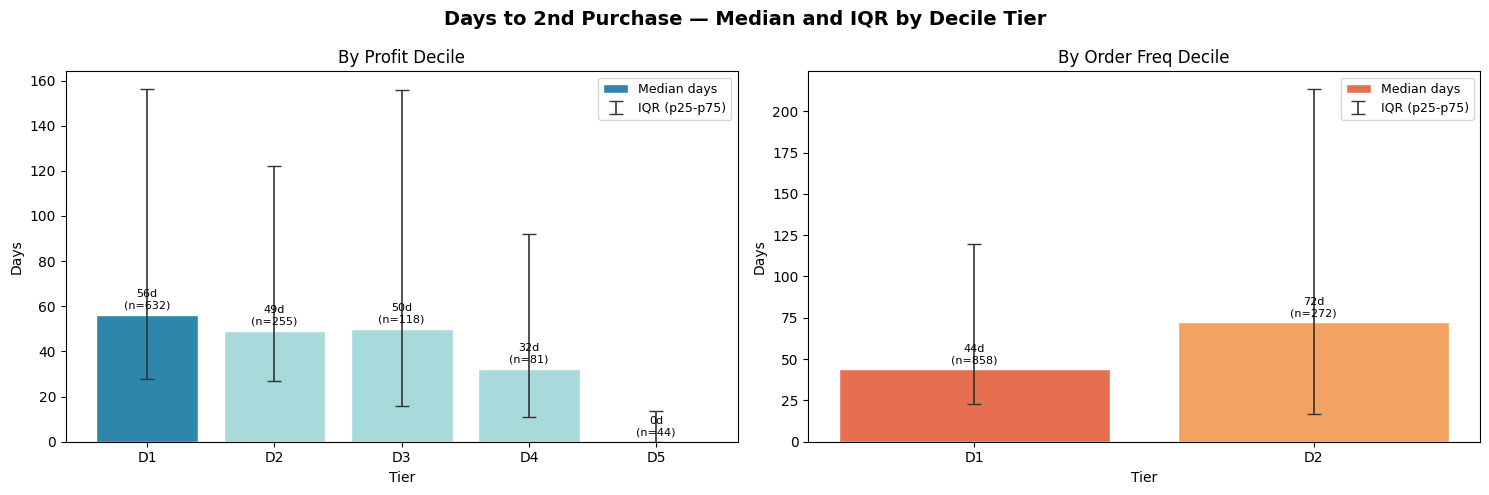

Saved: timebased_days_to_2nd_purchase.png

Key Findings:
- By profit decile: D1 customers who returned came back in a median of 56 days, with half returning between 28 and 156 days (IQR).
- The wide IQR for D1(profit) means there is no single right moment to re-engage them — some return within a month, others take up to 156 days.
- D5(profit) shows a median of 0 days — these customers placed two orders on the same day and are not genuine repeat buyers.
- By frequency decile: D1(freq) median is 44 days (IQR 23–120 days, n=858).


In [153]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Days to 2nd Purchase — Median and IQR by Decile Tier", fontsize=14, fontweight="bold")

for ax, summary, decile_col, title, color_d1 in [
    (axes[0], summary_2nd_profit,   "profit_decile", "By Profit Decile",        "#2E86AB"),
    (axes[1], summary_2nd_freq, "order_freq_decile",          "By Order Freq Decile", "#E76F51"),
]:
    colors = [color_d1 if t == "D1" else "#A8DADC" if color_d1 == "#2E86AB" else "#F4A261" for t in TIER_ORDER]
    bars = ax.bar(TIER_ORDER, summary["median_days"], color=colors, edgecolor="white", label="Median days")

    # IQR error bars (p25-p75)
    yerr_low  = summary["median_days"] - summary["p25_days"]
    yerr_high = summary["p75_days"] - summary["median_days"]
    ax.errorbar(
        TIER_ORDER, summary["median_days"],
        yerr=[yerr_low, yerr_high],
        fmt="none", color="#333333", capsize=5, linewidth=1.2,
        label="IQR (p25-p75)"
    )

    ax.set_title(title)
    ax.set_xlabel("Tier")
    ax.set_ylabel("Days")
    ax.legend(fontsize=9)
    for bar, val, n in zip(bars, summary["median_days"], summary["n_eligible"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f"{val:.0f}d\n(n={n})", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(FINALS_DIR / "timebased_days_to_2nd_purchase.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: timebased_days_to_2nd_purchase.png")


# --- Key Findings ---
d1_2nd_cm   = summary_2nd_cm[summary_2nd_cm["contribution_margin_decile"] == "D1"].iloc[0]
d5_2nd_cm   = summary_2nd_cm[summary_2nd_cm["contribution_margin_decile"] == "D5"].iloc[0]
d1_2nd_freq = summary_2nd_freq[summary_2nd_freq["order_freq_decile"] == "D1"].iloc[0]

print("\nKey Findings:")
print(f"""\
- By profit decile: D1 customers who returned came back in a median of {d1_2nd_cm['median_days']:.0f} days, \
with half returning between {d1_2nd_cm['p25_days']:.0f} and {d1_2nd_cm['p75_days']:.0f} days (IQR).
- The wide IQR for D1(profit) means there is no single right moment to re-engage them — \
some return within a month, others take up to {d1_2nd_cm['p75_days']:.0f} days.
- D5(profit) shows a median of {d5_2nd_cm['median_days']:.0f} days — these customers placed two orders \
on the same day and are not genuine repeat buyers.
- By frequency decile: D1(freq) median is {d1_2nd_freq['median_days']:.0f} days \
(IQR {d1_2nd_freq['p25_days']:.0f}–{d1_2nd_freq['p75_days']:.0f} days, n={int(d1_2nd_freq['n_eligible'])}).""")


## 6. Time to 3rd Purchase

Two sub-questions:
1. Days from 1st to 3rd order (overall commitment trajectory)
2. Days from 2nd to 3rd order (purchase cadence once a repeat pattern is established)

In [154]:
summary_3rd_profit_total     = days_to_nth_summary(df, "profit_decile", "days_to_third",   min_orders=3)
summary_3rd_freq_total   = days_to_nth_summary(df, "order_freq_decile",          "days_to_third",   min_orders=3)
summary_3rd_profit_cadence   = days_to_nth_summary(df, "profit_decile", "days_2nd_to_3rd", min_orders=3)
summary_3rd_freq_cadence = days_to_nth_summary(df, "order_freq_decile",          "days_2nd_to_3rd", min_orders=3)

print("TIME TO 3rd PURCHASE (from 1st order) — BY CM DECILE")
print(summary_3rd_profit_total.to_string(index=False, formatters=fmt_days))
print()
print("PURCHASE CADENCE: 2nd to 3rd order gap — BY CM DECILE")
print(summary_3rd_profit_cadence.to_string(index=False, formatters=fmt_days))

TIME TO 3rd PURCHASE (from 1st order) — BY CM DECILE
profit_decile  n_eligible median_days mean_days p25_days p75_days
           D1         353        138d      217d      64d     290d
           D2          85        120d      213d      56d     297d
           D3          19        153d      202d      66d     178d
           D4          15         75d       92d      15d     106d
           D5           3         24d       30d      12d      45d

PURCHASE CADENCE: 2nd to 3rd order gap — BY CM DECILE
profit_decile  n_eligible median_days mean_days p25_days p75_days
           D1         353         62d      108d      28d     117d
           D2          85         56d      115d      28d     180d
           D3          19         78d      154d      24d     133d
           D4          15         42d       60d       2d      67d
           D5           3          1d        8d       0d      12d


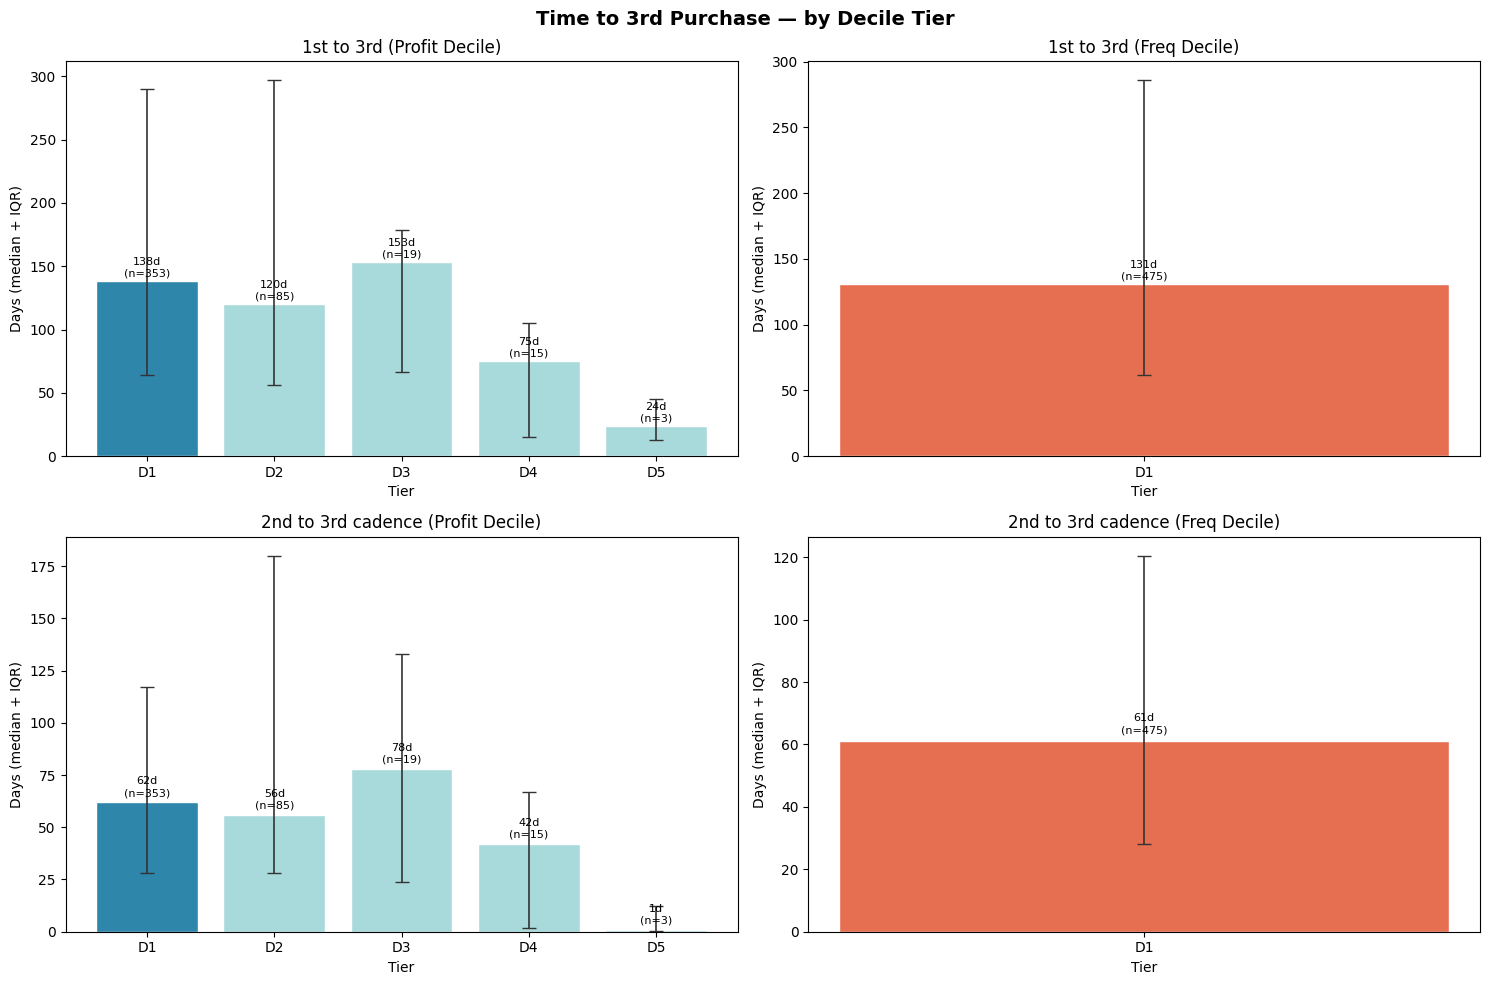

Saved: timebased_days_to_3rd_purchase.png

Key Findings:
- By profit decile: D1 customers who placed a 3rd order did so at a median of 138 days from their 1st purchase (~4.6 months).
- The gap between 2nd and 3rd purchase (62 days) is nearly identical to the 1st-to-2nd gap (56 days) — D1(profit) customers settle into a stable ~2-month buying rhythm once they return.
- By frequency decile: D1(freq) shows a 1st-to-3rd median of 131 days, with a 2nd-to-3rd cadence of 61 days (IQR 28–120 days).
- Sample sizes below D1 are too small to draw reliable conclusions.


In [155]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Time to 3rd Purchase — by Decile Tier", fontsize=14, fontweight="bold")

plot_configs = [
    (axes[0,0], summary_3rd_profit_total,     "1st to 3rd (Profit Decile)",          "#2E86AB"),
    (axes[0,1], summary_3rd_freq_total,   "1st to 3rd (Freq Decile)",        "#E76F51"),
    (axes[1,0], summary_3rd_profit_cadence,   "2nd to 3rd cadence (Profit Decile)",  "#2E86AB"),
    (axes[1,1], summary_3rd_freq_cadence, "2nd to 3rd cadence (Freq Decile)","#E76F51"),
]

for ax, summary, title, color_d1 in plot_configs:
    alt_color = "#A8DADC" if color_d1 == "#2E86AB" else "#F4A261"
    colors = [color_d1 if t == "D1" else alt_color for t in TIER_ORDER]
    bars = ax.bar(TIER_ORDER, summary["median_days"], color=colors, edgecolor="white")
    yerr_low  = summary["median_days"] - summary["p25_days"]
    yerr_high = summary["p75_days"] - summary["median_days"]
    ax.errorbar(TIER_ORDER, summary["median_days"],
                yerr=[yerr_low, yerr_high],
                fmt="none", color="#333333", capsize=5, linewidth=1.2)
    ax.set_title(title)
    ax.set_xlabel("Tier")
    ax.set_ylabel("Days (median + IQR)")
    for bar, val, n in zip(bars, summary["median_days"], summary["n_eligible"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f"{val:.0f}d\n(n={n})", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(FINALS_DIR / "timebased_days_to_3rd_purchase.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: timebased_days_to_3rd_purchase.png")

# --- Key Findings ---
d1_3rd_cm  = summary_3rd_cm_total[summary_3rd_cm_total["contribution_margin_decile"] == "D1"].iloc[0]
d1_cad_cm  = summary_3rd_cm_cadence[summary_3rd_cm_cadence["contribution_margin_decile"] == "D1"].iloc[0]
d1_2nd_ref = summary_2nd_cm[summary_2nd_cm["contribution_margin_decile"] == "D1"].iloc[0]
d1_3rd_freq = summary_3rd_freq_total[summary_3rd_freq_total["order_freq_decile"] == "D1"].iloc[0]
d1_cad_freq = summary_3rd_freq_cadence[summary_3rd_freq_cadence["order_freq_decile"] == "D1"].iloc[0]

print("\nKey Findings:")
print(f"""\
- By profit decile: D1 customers who placed a 3rd order did so at a median of {d1_3rd_cm['median_days']:.0f} days \
from their 1st purchase (~{d1_3rd_cm['median_days']/30:.1f} months).
- The gap between 2nd and 3rd purchase ({d1_cad_cm['median_days']:.0f} days) is nearly identical to \
the 1st-to-2nd gap ({d1_2nd_ref['median_days']:.0f} days) — D1(profit) customers settle into a stable \
~{round((d1_cad_cm['median_days'] + d1_2nd_ref['median_days']) / 2 / 30)}-month buying rhythm once they return.
- By frequency decile: D1(freq) shows a 1st-to-3rd median of {d1_3rd_freq['median_days']:.0f} days, \
with a 2nd-to-3rd cadence of {d1_cad_freq['median_days']:.0f} days (IQR {d1_cad_freq['p25_days']:.0f}–{d1_cad_freq['p75_days']:.0f} days).
- Sample sizes below D1 are too small to draw reliable conclusions.""")

## 7. Recency / Churn Signal

`recency_days` = days since the customer's last order, measured from the data end date (2026-03-30).
We classify customers into three buckets:

| Bucket | Criterion | Meaning |
|--------|-----------|---------|
| Active | recency < 90 days | Recent purchase, still engaged |
| At-risk | 90 to 180 days | Going quiet |
| Likely churned | recency >= 180 days | No purchase in 6+ months |

In [167]:
def recency_status(days):
    if days < AT_RISK_DAYS:
        return "Active"
    elif days < CHURN_DAYS:
        return "At-risk"
    else:
        return "Likely churned"

df["recency_status"] = df["recency_days"].apply(recency_status)

def recency_summary(df, decile_col):
    rows = []
    for tier in TIER_ORDER:
        grp = df[df[decile_col] == tier]
        n = len(grp)
        counts = grp["recency_status"].value_counts()
        rows.append({
            decile_col: tier,
            "n_customers": n,
            "median_recency_days": grp["recency_days"].median(),
            "pct_active":  counts.get("Active", 0) / n,
            "pct_at_risk": counts.get("At-risk", 0) / n,
            "pct_churned": counts.get("Likely churned", 0) / n,
        })
    return pd.DataFrame(rows)

rec_profit   = recency_summary(df, "profit_decile")
rec_freq = recency_summary(df, "order_freq_decile")

fmt_rec = {"median_recency_days": "{:.0f}d".format,
           "pct_active": "{:.1%}".format, "pct_at_risk": "{:.1%}".format, "pct_churned": "{:.1%}".format}

print("RECENCY SUMMARY — BY PROFIT DECILE")
print(f"(Active = <{AT_RISK_DAYS}d, At-risk = {AT_RISK_DAYS}-{CHURN_DAYS}d, Likely churned = >={CHURN_DAYS}d)")
print(rec_profit.to_string(index=False, formatters=fmt_rec))
print()
print("RECENCY SUMMARY — BY ORDER FREQUENCY DECILE")
print(rec_freq.to_string(index=False, formatters=fmt_rec))

RECENCY SUMMARY — BY PROFIT DECILE
(Active = <90d, At-risk = 90-180d, Likely churned = >=180d)
profit_decile  n_customers median_recency_days pct_active pct_at_risk pct_churned
           D1          858                380d      16.7%        5.6%       77.7%
           D2          858                428d      15.2%        5.6%       79.3%
           D3          858                413d      13.4%        5.9%       80.7%
           D4          858                710d       6.6%        3.6%       89.7%
           D5          858                609d       4.4%        2.7%       92.9%

RECENCY SUMMARY — BY ORDER FREQUENCY DECILE
order_freq_decile  n_customers median_recency_days pct_active pct_at_risk pct_churned
               D1          858                363d      16.4%        5.7%       77.9%
               D2          858                124d      37.8%       16.8%       45.5%
               D3          858                334d       0.9%        0.3%       98.7%
               D4       

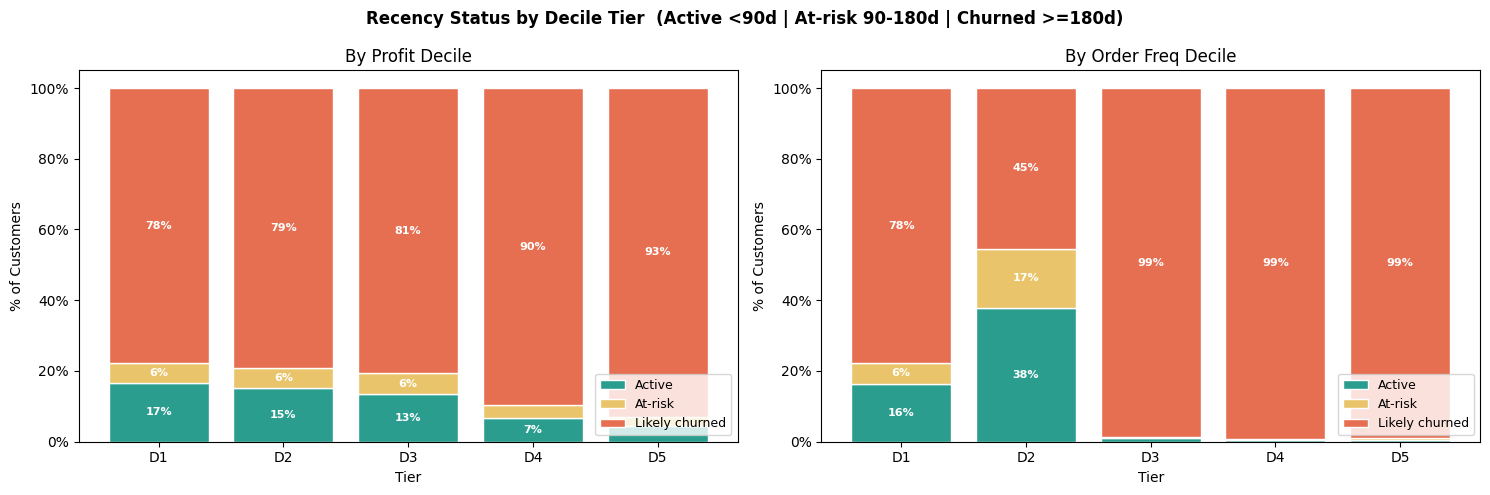

Saved: timebased_recency_status.png

Key Findings:
- By profit decile: 77.7% of D1(profit) customers have not purchased in over 180 days — flagged as likely churned. Their median last order was 380 days ago.
- Even the best customers by profit have largely gone quiet. D5(profit) is worse at 92.9% likely churned, but the gap between D1 and D5 is smaller than expected.
- By frequency decile: D1(freq) has 16.4% still active (median recency 363 days).
- One bright spot: D2(freq) is the most recently active segment — 37.8% active, with a median recency of 124 days. These recent 2-order customers are worth watching.


In [168]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(
    f"Recency Status by Decile Tier  "
    f"(Active <{AT_RISK_DAYS}d | At-risk {AT_RISK_DAYS}-{CHURN_DAYS}d | Churned >={CHURN_DAYS}d)",
    fontsize=12, fontweight="bold"
)

status_colors = {"Active": "#2A9D8F", "At-risk": "#E9C46A", "Likely churned": "#E76F51"}

for ax, rec_df, decile_col, title in [
    (axes[0], rec_profit,   "profit_decile", "By Profit Decile"),
    (axes[1], rec_freq, "order_freq_decile",           "By Order Freq Decile"),
]:
    bottoms = np.zeros(N_TIERS)
    for status, col in [("Active", "pct_active"), ("At-risk", "pct_at_risk"), ("Likely churned", "pct_churned")]:
        vals = rec_df[col].values * 100
        bars = ax.bar(TIER_ORDER, vals, bottom=bottoms, color=status_colors[status],
                      edgecolor="white", label=status)
        for i, (bar, v, b) in enumerate(zip(bars, vals, bottoms)):
            if v > 5:
                ax.text(bar.get_x() + bar.get_width()/2, b + v/2,
                        f"{v:.0f}%", ha="center", va="center", fontsize=8, color="white", fontweight="bold")
        bottoms += vals
    ax.set_title(title)
    ax.set_xlabel("Tier")
    ax.set_ylabel("% of Customers")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
    ax.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig(FINALS_DIR / "timebased_recency_status.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: timebased_recency_status.png")

# --- Key Findings ---
d1_rec_profit   = rec_profit[rec_profit["profit_decile"] == "D1"].iloc[0]
d5_rec_profit   = rec_profit[rec_profit["profit_decile"] == "D5"].iloc[0]
d1_rec_freq = rec_freq[rec_freq["order_freq_decile"] == "D1"].iloc[0]
d2_rec_freq = rec_freq[rec_freq["order_freq_decile"] == "D2"].iloc[0]

print("\nKey Findings:")
print(f"""\
- By profit decile: {d1_rec_profit['pct_churned']:.1%} of D1(profit) customers have not purchased \
in over {CHURN_DAYS} days — flagged as likely churned. Their median last order was {d1_rec_profit['median_recency_days']:.0f} days ago.
- Even the best customers by profit have largely gone quiet. D5(profit) is worse at \
{d5_rec_profit['pct_churned']:.1%} likely churned, but the gap between D1 and D5 is smaller than expected.
- By frequency decile: D1(freq) has {d1_rec_freq['pct_active']:.1%} still active \
(median recency {d1_rec_freq['median_recency_days']:.0f} days).
- One bright spot: D2(freq) is the most recently active segment — {d2_rec_freq['pct_active']:.1%} active, \
with a median recency of {d2_rec_freq['median_recency_days']:.0f} days. These recent 2-order customers are worth watching.""")

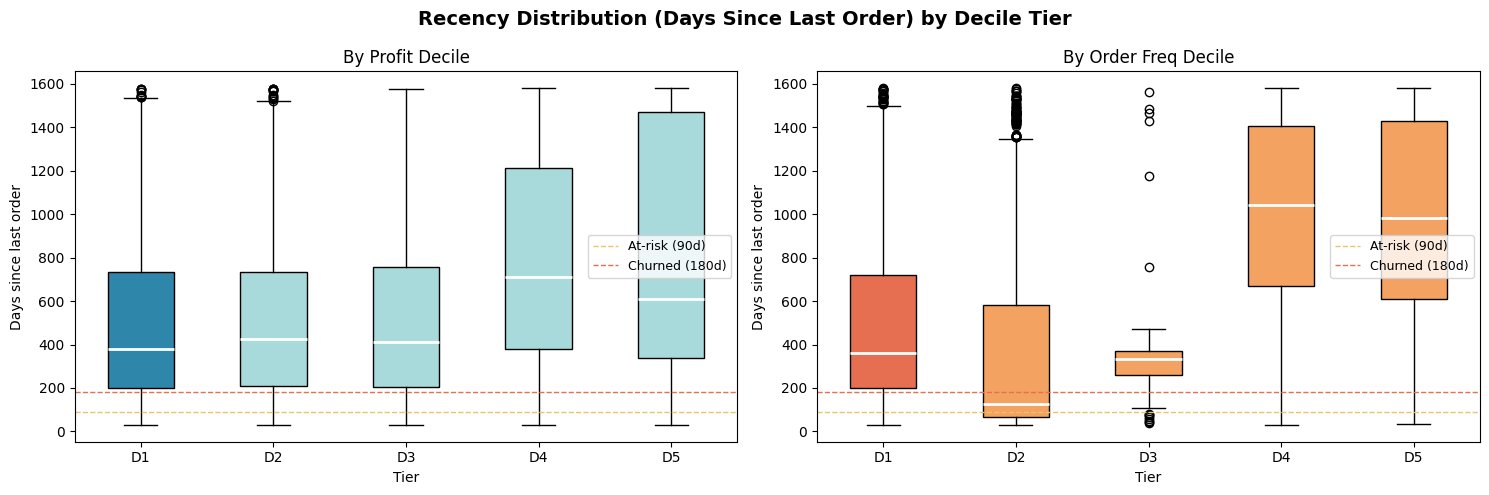

Saved: timebased_recency_boxplot.png


In [169]:
# Boxplot: recency distribution by decile
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Recency Distribution (Days Since Last Order) by Decile Tier", fontsize=14, fontweight="bold")

for ax, decile_col, title, color in [
    (axes[0], "profit_decile", "By Profit Decile",         "#2E86AB"),
    (axes[1], "order_freq_decile",          "By Order Freq Decile",  "#E76F51"),
]:
    data = [df[df[decile_col] == tier]["recency_days"].dropna().values for tier in TIER_ORDER]
    bp = ax.boxplot(data, labels=TIER_ORDER, patch_artist=True,
                    medianprops={"color": "white", "linewidth": 2})
    for patch, tier in zip(bp["boxes"], TIER_ORDER):
        patch.set_facecolor(color if tier == "D1" else "#A8DADC" if color == "#2E86AB" else "#F4A261")
    ax.axhline(AT_RISK_DAYS, color="#E9C46A", linestyle="--", linewidth=1, label=f"At-risk ({AT_RISK_DAYS}d)")
    ax.axhline(CHURN_DAYS,   color="#E76F51", linestyle="--", linewidth=1, label=f"Churned ({CHURN_DAYS}d)")
    ax.set_title(title)
    ax.set_xlabel("Tier")
    ax.set_ylabel("Days since last order")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FINALS_DIR / "timebased_recency_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: timebased_recency_boxplot.png")

## 8. Retention at Milestones (3 / 6 / 12 months)

For each customer, did they place a repeat purchase within 3 / 6 / 12 months of their first order?

**Scope note:** we only include customers whose first order is at least N months before the data end date.

In [170]:
def retention_at_milestone(df, decile_col, milestone_days, reference_date):
    cutoff = reference_date - pd.Timedelta(days=milestone_days)
    eligible = df[df["first_order_date"] <= cutoff].copy()
    eligible["repeat_within"] = (
        eligible["second_order_date"].notna() &
        ((eligible["second_order_date"] - eligible["first_order_date"]).dt.total_seconds() / 86400 <= milestone_days)
    )
    rows = []
    for tier in TIER_ORDER:
        grp = eligible[eligible[decile_col] == tier]
        n = len(grp)
        pct = grp["repeat_within"].mean() if n > 0 else np.nan
        rows.append({decile_col: tier, "n_eligible": n, f"pct_repeat_{milestone_days}d": pct})
    return pd.DataFrame(rows)

milestones = [90, 180, 365]
ret_profit = ret_freq = None

for m in milestones:
    r_profit   = retention_at_milestone(df, "profit_decile", m, REFERENCE_DATE)
    r_freq = retention_at_milestone(df, "order_freq_decile",           m, REFERENCE_DATE)
    ret_profit   = r_profit if ret_profit   is None else ret_profit.merge(r_profit[["profit_decile", f"pct_repeat_{m}d"]], on="profit_decile")
    ret_freq = r_freq if ret_freq is None else ret_freq.merge(r_freq[["order_freq_decile", f"pct_repeat_{m}d"]], on="order_freq_decile")

fmt_ret = {f"pct_repeat_{m}d": "{:.1%}".format for m in milestones}

print("RETENTION AT MILESTONES — BY PROFIT DECILE")
print("(% who placed a 2nd order within N days of 1st purchase, among customers old enough to qualify)")
print(ret_profit.to_string(index=False, formatters=fmt_ret))
print()
print("RETENTION AT MILESTONES — BY ORDER FREQUENCY DECILE")
print(ret_freq.to_string(index=False, formatters=fmt_ret))

RETENTION AT MILESTONES — BY PROFIT DECILE
(% who placed a 2nd order within N days of 1st purchase, among customers old enough to qualify)
profit_decile  n_eligible pct_repeat_90d pct_repeat_180d pct_repeat_365d
           D1         797          46.4%           60.3%           70.2%
           D2         711          22.1%           28.8%           37.2%
           D3         719          10.7%           12.7%           15.5%
           D4         786           7.6%            9.2%           10.4%
           D5         807           5.2%            5.5%            7.2%

RETENTION AT MILESTONES — BY ORDER FREQUENCY DECILE
order_freq_decile  n_eligible pct_repeat_90d pct_repeat_180d pct_repeat_365d
               D1         817          68.5%           83.0%           91.5%
               D2         449          32.5%           71.2%           85.0%
               D3         849           0.0%            0.0%            0.0%
               D4         852           0.0%            0.0%  

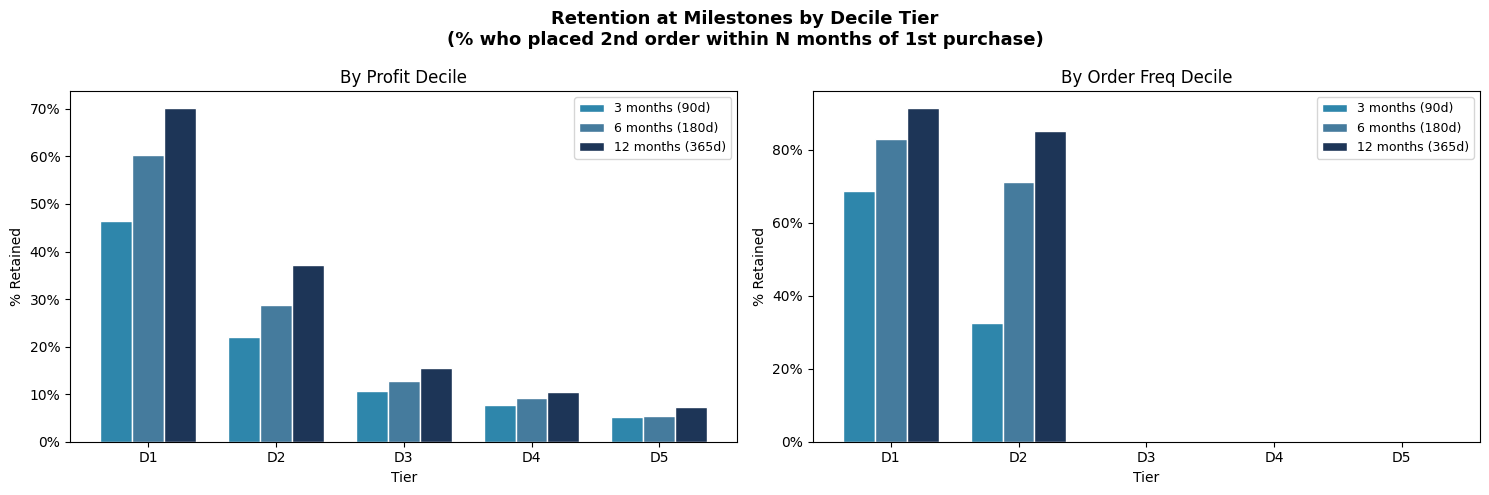

Saved: timebased_retention_milestones.png

Key Findings:
- By profit decile: of D1(profit) customers, 46.4% returned within 3 months, 60.3% within 6 months, and 70.2% within 12 months.
- The retention curve for D1(profit) is still rising at 12 months — writing them off at 3 months would be premature.
- D5(profit) flatlines at 5.2% / 5.5% / 7.2% across all three windows — they very rarely return at any point.
- By frequency decile: D1(freq) retention is 68.5% at 3 months, 83.0% at 6 months, and 91.5% at 12 months.


In [171]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Retention at Milestones by Decile Tier\n(% who placed 2nd order within N months of 1st purchase)",
             fontsize=13, fontweight="bold")

x = np.arange(N_TIERS)
width = 0.25
milestone_labels = ["3 months (90d)", "6 months (180d)", "12 months (365d)"]
milestone_colors = ["#2E86AB", "#457B9D", "#1D3557"]

for ax, ret_df, decile_col, title in [
    (axes[0], ret_profit,   "profit_decile", "By Profit Decile"),
    (axes[1], ret_freq, "order_freq_decile",           "By Order Freq Decile"),
]:
    for i, (m, label, color) in enumerate(zip(milestones, milestone_labels, milestone_colors)):
        col = f"pct_repeat_{m}d"
        ax.bar(x + i * width, ret_df[col] * 100, width, label=label, color=color, edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("Tier")
    ax.set_ylabel("% Retained")
    ax.set_xticks(x + width)
    ax.set_xticklabels(TIER_ORDER)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FINALS_DIR / "timebased_retention_milestones.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: timebased_retention_milestones.png")

# --- Key Findings ---
d1_ret_profit   = ret_profit[ret_profit["profit_decile"] == "D1"].iloc[0]
d5_ret_profit   = ret_profit[ret_profit["profit_decile"] == "D5"].iloc[0]
d1_ret_freq = ret_freq[ret_freq["order_freq_decile"] == "D1"].iloc[0]

print("\nKey Findings:")
print(f"""\
- By profit decile: of D1(profit) customers, {d1_ret_profit['pct_repeat_90d']:.1%} returned within 3 months, \
{d1_ret_profit['pct_repeat_180d']:.1%} within 6 months, and {d1_ret_profit['pct_repeat_365d']:.1%} within 12 months.
- The retention curve for D1(profit) is still rising at 12 months — writing them off at 3 months would be premature.
- D5(profit) flatlines at {d5_ret_profit['pct_repeat_90d']:.1%} / {d5_ret_profit['pct_repeat_180d']:.1%} / \
{d5_ret_profit['pct_repeat_365d']:.1%} across all three windows — they very rarely return at any point.
- By frequency decile: D1(freq) retention is {d1_ret_freq['pct_repeat_90d']:.1%} at 3 months, \
{d1_ret_freq['pct_repeat_180d']:.1%} at 6 months, and {d1_ret_freq['pct_repeat_365d']:.1%} at 12 months.""")


## 9. Customer Lifespan

For repeat buyers only: days between first and last order.

In [172]:
# Only meaningful for repeat buyers
repeaters = df[df["finals_orders"] >= 2].copy()

def lifespan_summary(df, decile_col):
    rows = []
    for tier in TIER_ORDER:
        grp = df[df[decile_col] == tier]["lifespan_days"].dropna()
        rows.append({
            decile_col: tier,
            "n_repeaters": len(grp),
            "median_lifespan": grp.median(),
            "mean_lifespan":   grp.mean(),
            "p25": grp.quantile(0.25),
            "p75": grp.quantile(0.75),
        })
    return pd.DataFrame(rows)

life_profit   = lifespan_summary(repeaters, "profit_decile")
life_freq = lifespan_summary(repeaters, "order_freq_decile")

fmt_life = {"median_lifespan": "{:.0f}d".format, "mean_lifespan": "{:.0f}d".format,
            "p25": "{:.0f}d".format, "p75": "{:.0f}d".format}

print("CUSTOMER LIFESPAN (repeat buyers only) — BY PROFIT DECILE")
print(life_profit.to_string(index=False, formatters=fmt_life))
print()
print("CUSTOMER LIFESPAN (repeat buyers only) — BY FREQ DECILE")
print(life_freq.to_string(index=False, formatters=fmt_life))

CUSTOMER LIFESPAN (repeat buyers only) — BY PROFIT DECILE
profit_decile  n_repeaters median_lifespan mean_lifespan p25  p75
           D1          632            190d          298d 73d 420d
           D2          255             84d          166d 28d 233d
           D3          118             64d          191d 24d 210d
           D4           81             42d           94d 11d 104d
           D5           44              0d           41d  0d  22d

CUSTOMER LIFESPAN (repeat buyers only) — BY FREQ DECILE
order_freq_decile  n_repeaters median_lifespan mean_lifespan p25  p75
               D1          858            151d          252d 44d 364d
               D2          272             72d          170d 17d 214d
               D3            0             NaN           NaN NaN  NaN
               D4            0             NaN           NaN NaN  NaN
               D5            0             NaN           NaN NaN  NaN


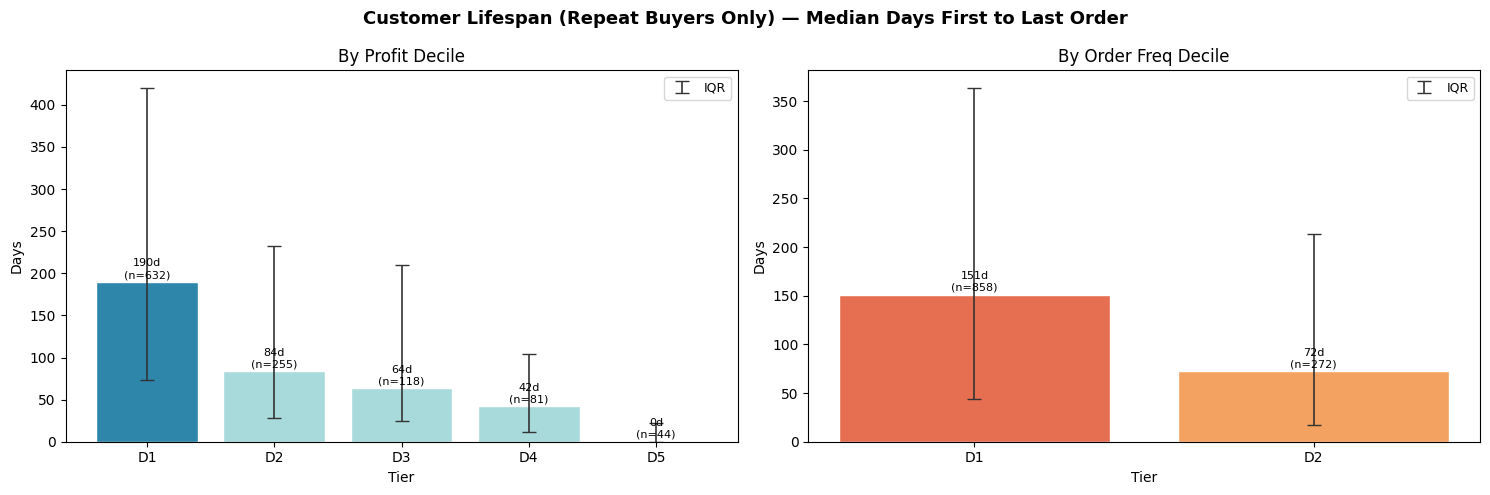

Saved: timebased_customer_lifespan.png

Key Findings:
- By profit decile: D1 repeat buyers stayed engaged for a median of 190 days between their first and last order. The top 25% were active for over 420 days (~14 months).
- Lifespan drops sharply below D1: D2(profit) = 84 days.
- D5(profit) median is 0 days — confirming these are same-day split orders, not recurring customers.
- By frequency decile: D1(freq) median lifespan is 151 days (IQR 44–364 days, n=858).
- A 6-month retention window may be too short for D1(profit) — a meaningful portion of top customers are still winnable beyond that point.


In [173]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Customer Lifespan (Repeat Buyers Only) — Median Days First to Last Order",
             fontsize=13, fontweight="bold")

for ax, life_df, decile_col, title, color_d1 in [
    (axes[0], life_profit,   "profit_decile", "By Profit Decile",        "#2E86AB"),
    (axes[1], life_freq, "order_freq_decile",           "By Order Freq Decile", "#E76F51"),
]:
    alt = "#A8DADC" if color_d1 == "#2E86AB" else "#F4A261"
    colors = [color_d1 if t == "D1" else alt for t in TIER_ORDER]
    bars = ax.bar(TIER_ORDER, life_df["median_lifespan"], color=colors, edgecolor="white")
    yerr_low  = life_df["median_lifespan"] - life_df["p25"]
    yerr_high = life_df["p75"] - life_df["median_lifespan"]
    ax.errorbar(TIER_ORDER, life_df["median_lifespan"],
                yerr=[yerr_low, yerr_high],
                fmt="none", color="#333333", capsize=5, linewidth=1.2, label="IQR")
    ax.set_title(title)
    ax.set_xlabel("Tier")
    ax.set_ylabel("Days")
    ax.legend(fontsize=9)
    for bar, val, n in zip(bars, life_df["median_lifespan"], life_df["n_repeaters"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f"{val:.0f}d\n(n={n})", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(FINALS_DIR / "timebased_customer_lifespan.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: timebased_customer_lifespan.png")

# --- Key Findings ---
d1_life_profit = life_profit[life_profit["profit_decile"] == "D1"].iloc[0]
d2_life_profit = life_profit[life_profit["profit_decile"] == "D2"].iloc[0]
d5_life_profit = life_profit[life_profit["profit_decile"] == "D5"].iloc[0]
d1_life_freq = life_freq[life_freq["order_freq_decile"] == "D1"].iloc[0]

print("\nKey Findings:")
print(f"""\
- By profit decile: D1 repeat buyers stayed engaged for a median of {d1_life_profit['median_lifespan']:.0f} days \
between their first and last order. The top 25% were active for over {d1_life_profit['p75']:.0f} days \
(~{d1_life_profit['p75']/30:.0f} months).
- Lifespan drops sharply below D1: D2(profit) = {d2_life_profit['median_lifespan']:.0f} days.
- D5(profit) median is {d5_life_profit['median_lifespan']:.0f} days — confirming these are same-day split orders, \
not recurring customers.
- By frequency decile: D1(freq) median lifespan is {d1_life_freq['median_lifespan']:.0f} days \
(IQR {d1_life_freq['p25']:.0f}–{d1_life_freq['p75']:.0f} days, n={int(d1_life_freq['n_repeaters'])}).
- A 6-month retention window may be too short for D1(profit) — a meaningful portion of top customers \
are still winnable beyond that point.""")

## 10. Export — Time-Based Summary Table

In [174]:
export_cols = [
    "customer_id",
    "contribution_margin_decile", "order_freq_decile",
    "finals_orders",
    "days_to_second", "days_to_third", "days_2nd_to_3rd",
    "lifespan_days", "recency_days", "recency_status",
    "first_order_date", "last_order_date",
]

export_df = df[[c for c in export_cols if c in df.columns]].copy()

out_path = FINALS_DIR / "decile_timebased_table.csv"
export_df.to_csv(out_path, index=False)

print(f"Saved: {out_path}")
print(f"Rows : {len(export_df):,}")
print()
display(export_df.head(5))

Saved: C:\Users\saeli\Downloads\LushProtein prj\lushprotein\EDA\outputs_finals\decile_timebased_table.csv
Rows : 4,290



,customer_id,order_freq_decile,finals_orders,days_to_second,days_to_third,days_2nd_to_3rd,lifespan_days,recency_days,recency_status,first_order_date,last_order_date
0,7756044599551,D1,2,22.0,NaN,NaN,22,1545,Likely churned,2022-01-13 16:00:00+00:00,2022-02-04 16:00:00+00:00
1,7756032868607,D4,1,NaN,NaN,NaN,0,1428,Likely churned,2022-06-01 16:00:00+00:00,2022-06-01 16:00:00+00:00
2,8712766128383,D2,1,NaN,NaN,NaN,0,96,At-risk,2026-01-23 16:00:00+00:00,2026-01-23 16:00:00+00:00
3,7964005826815,D1,2,62.0,NaN,NaN,62,316,Likely churned,2025-04-16 16:00:00+00:00,2025-06-17 16:00:00+00:00
4,7958758916351,D3,1,NaN,NaN,NaN,0,381,Likely churned,2025-04-13 16:00:00+00:00,2025-04-13 16:00:00+00:00


## 11. Summary

In [175]:
print("=" * 65)
print("LUSHPROTEIN DECILE — TIME-BASED ANALYSIS SUMMARY")
print("=" * 65)
print(f"\nCustomer pool : {len(df):,}")
print(f"Reference date (data end) : {REFERENCE_DATE.date()}")

print("\n--- REPEAT PURCHASE FUNNEL (Profit Decile) ---")
for _, row in funnel_profit.iterrows():
    print(f"  {row['profit_decile']}: {row['pct_2plus']:.0%} had >=2 orders, {row['pct_3plus']:.0%} had >=3")

print("\n--- MEDIAN DAYS TO 2nd PURCHASE (Profit Decile, repeat buyers only) ---")
for _, row in summary_2nd_profit.iterrows():
    print(f"  {row['profit_decile']}: {row['median_days']:.0f} days  (n={int(row['n_eligible'])})")

print("\n--- RECENCY STATUS — D1 Profit vs D5 Profit ---")
for tier in ["D1", "D5"]:
    r = rec_profit[rec_profit["profit_decile"] == tier].iloc[0]
    print(f"  {tier}: {r['pct_active']:.0%} active | {r['pct_at_risk']:.0%} at-risk | {r['pct_churned']:.0%} likely churned")

print("\n--- OUTPUTS ---")
for fname in [
    "decile_timebased_table.csv",
    "timebased_repeat_purchase_funnel.png",
    "timebased_days_to_2nd_purchase.png",
    "timebased_days_to_3rd_purchase.png",
    "timebased_recency_status.png",
    "timebased_recency_boxplot.png",
    "timebased_retention_milestones.png",
    "timebased_customer_lifespan.png",
]:
    print(f"  {fname}")
print("=" * 65)

LUSHPROTEIN DECILE — TIME-BASED ANALYSIS SUMMARY

Customer pool : 4,290
Reference date (data end) : 2026-03-30

--- REPEAT PURCHASE FUNNEL (Profit Decile) ---
  D1: 74% had >=2 orders, 41% had >=3
  D2: 30% had >=2 orders, 10% had >=3
  D3: 14% had >=2 orders, 2% had >=3
  D4: 9% had >=2 orders, 2% had >=3
  D5: 5% had >=2 orders, 0% had >=3

--- MEDIAN DAYS TO 2nd PURCHASE (Profit Decile, repeat buyers only) ---
  D1: 56 days  (n=632)
  D2: 49 days  (n=255)
  D3: 50 days  (n=118)
  D4: 32 days  (n=81)
  D5: 0 days  (n=44)

--- RECENCY STATUS — D1 Profit vs D5 Profit ---
  D1: 17% active | 6% at-risk | 78% likely churned
  D5: 4% active | 3% at-risk | 93% likely churned

--- OUTPUTS ---
  decile_timebased_table.csv
  timebased_repeat_purchase_funnel.png
  timebased_days_to_2nd_purchase.png
  timebased_days_to_3rd_purchase.png
  timebased_recency_status.png
  timebased_recency_boxplot.png
  timebased_retention_milestones.png
  timebased_customer_lifespan.png


---

## Note to Emily — Business Strategy Directions for CEO

Based on the analysis above, here are five directions worth exploring for the CEO recommendation. These are starting points — happy to discuss further.

**1. Convert the 2nd purchase — it is the most critical moment**
73.7% of D1 customers returned, but only 29.7% of D2 did. The jump between D1 and D2 is the single biggest drop-off in the entire funnel. A targeted campaign to nudge D2-D3 customers back within their first 56 days (before they go cold) could move a meaningful number up into D1 territory. Think: post-purchase email sequence, personalised reorder reminder, or a time-limited loyalty incentive.

**2. Reactivate churned D1 customers — highest ROI opportunity**
78% of our most profitable customers have not bought in over 6 months. Even recovering 10% of them (~67 customers x avg S$230 profit) would generate ~S$15,400 in profit without any new customer acquisition cost. A win-back campaign targeting D1 likely-churned (last order 180-365 days ago) is likely the fastest path to revenue recovery.

**3. Build a subscription or replenishment nudge around the 60-day cadence**
D1 customers who reach their 3rd purchase naturally fall into a ~60-day buying rhythm. This is the natural window to introduce a subscription tier or automated replenishment reminder — aligning the offer to when they already want to buy, rather than pushing against behaviour.

**4. Do not over-invest in reactivating D3-D5**
D3-D5 are structurally one-time buyers — 0% of D3-D5 (by frequency) ever returned, and D5 retention flatlines at 5-7% even at 12 months. Marketing spend on these tiers is likely better redirected toward acquiring new customers who resemble D1's profile (first product category, acquisition channel, etc.).

**5. Protect recently active D2 frequency customers**
The D2 frequency group is the most recently active segment (37.8% active, median recency 124 days). These customers are in a window where a well-timed nudge could convert them from 2-order buyers into D1-tier loyalists. Worth a dedicated retention play before they go quiet.